# P2 — Credit Risk Scoring

## 01 — Préparation des données

Ce projet vise à construire un modèle de **scoring de risque de crédit** à partir des données historiques de Lending Club.

L’objectif est d’estimer la probabilité qu’un prêt soit en défaut (*Charged Off*) au moment de son octroi.

- **Unité d’observation :** un prêt accordé
- **Cible :** indicateur binaire de défaut
- **Population :** prêts dont l’issue est connue, soit `Fully Paid` ou `Charged Off`
- **Principe de modélisation :** utiliser exclusivement les variables connues lors de l’octroi afin d’éviter toute fuite d’information

> Ce projet est une démonstration de modélisation du risque de crédit. Il ne constitue pas un modèle de décision de crédit utilisable en production.



In [2]:
# ============================================================
# 1. IMPORTS ET CONFIGURATION GLOBALE
# ============================================================

# Standard library
from pathlib import Path
import gc
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Configuration d'affichage et de visualisation
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)


# ------------------------------------------------------------
# Chemins du projet
# ------------------------------------------------------------

def find_project_root(start_path: Path) -> Path:
    """
    Remonte les dossiers parents jusqu'à trouver la racine du projet,
    identifiée par le fichier pyproject.toml.
    """
    current_path = start_path.resolve()

    for candidate_path in [current_path, *current_path.parents]:
        if (candidate_path / "pyproject.toml").exists():
            return candidate_path

    raise FileNotFoundError(
        "Racine du projet introuvable : pyproject.toml absent."
    )


PROJECT_DIR = find_project_root(Path.cwd())

DATA_RAW_DIR = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUT_DIR / "tables"
OUTPUT_MODELS_DIR = OUTPUT_DIR / "models"

RAW_FILE = DATA_RAW_DIR / "lending_club_accepted_raw.csv"


# Création défensive des dossiers nécessaires
for directory in [
    DATA_PROCESSED_DIR,
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Contrôles de démarrage
# ------------------------------------------------------------

assert RAW_FILE.exists(), (
    f"Fichier source introuvable : {RAW_FILE}"
)

print(f"Racine projet  : {PROJECT_DIR}")
print(f"Fichier source : {RAW_FILE.name}")
print(f"Taille source  : {RAW_FILE.stat().st_size / 1024**3:.2f} Go")


Racine projet  : /Users/kwamekristianlaban/Documents/Projet_perso/P2
Fichier source : lending_club_accepted_raw.csv
Taille source  : 1.56 Go


## Inspection du fichier source

Le fichier Lending Club contient des informations historiques sur les prêts acceptés. Avant toute transformation, nous vérifions sa structure, les types de variables et un échantillon de données.

Le fichier est volumineux : l'exploration initiale est donc réalisée sans charger l'intégralité des données en mémoire.


In [3]:
# ============================================================
# 2. INSPECTION DU FICHIER SOURCE
# ============================================================

# Lecture de l'en-tête uniquement : aucune ligne de données n'est chargée.
raw_columns = pd.read_csv(
    RAW_FILE,
    nrows=0,
    low_memory=False
).columns.tolist()

print(f"Nombre de colonnes : {len(raw_columns)}")

print("\nPremières colonnes :")
print(raw_columns[:25])

print("\nDernières colonnes :")
print(raw_columns[-25:])


Nombre de colonnes : 151

Premières colonnes :
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti']

Dernières colonnes :
['sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term']


In [4]:
# Lecture d'un échantillon très limité pour comprendre les formats bruts.
raw_sample = pd.read_csv(
    RAW_FILE,
    nrows=5,
    low_memory=False
)

display(raw_sample)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,"3,600.0000","3,600.0000","3,600.0000",36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,"55,000.0000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,"2,765.0000",29.7000,13.0000,w,0.0000,0.0000,"4,421.7239","4,421.7200","3,600.0000",821.7200,0.0000,0.0000,0.0000,Jan-2019,122.6700,NaN,Mar-2019,564.0000,560.0000,0.0000,30.0000,1.0000,Individual,NaN,NaN,NaN,0.0000,722.0000,"144,904.0000",2.0000,2.0000,0.0000,1.0000,21.0000,"4,981.0000",36.0000,3.0000,3.0000,722.0000,34.0000,"9,300.0000",3.0000,1.0000,4.0000,4.0000,"20,701.0000","1,506.0000",37.2000,0.0000,0.0000,148.0000,128.0000,3.0000,3.0000,1.0000,4.0000,69.0000,4.0000,69.0000,2.0000,2.0000,4.0000,2.0000,5.0000,3.0000,4.0000,9.0000,4.0000,7.0000,0.0000,0.0000,0.0000,3.0000,76.9000,0.0000,0.0000,0.0000,"178,050.0000","7,746.0000","2,400.0000","13,734.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,"24,700.0000","24,700.0000","24,700.0000",36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,"65,000.0000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,"21,470.0000",19.2000,38.0000,w,0.0000,0.0000,"25,679.6600","25,679.6600","24,700.0000",979.6600,0.0000

### Lecture initiale

Le fichier contient de nombreuses variables couvrant le montant, les caractéristiques du demandeur, l'historique de crédit et les événements
observés après l'octroi.

Toutes les variables ne sont pas exploitables pour un modèle de PD :
 - les montants remboursés, recouvrements, dates de paiement et scores de crédit mis à jour après l'octroi seront exclus pour empêcher toute fuite d'information.

La sélection finale portera uniquement sur les variables disponibles lors de la décision d'octroi.


In [5]:
#Variable critiques
critical_columns = [
    "id",
    "issue_d",
    "loan_status",
    "term",
    "loan_amnt",
    "int_rate",
    "grade",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
]

critical_columns_check = pd.DataFrame({
    "column": critical_columns,
    "available": [
        column in raw_columns
        for column in critical_columns
    ]
})

display(critical_columns_check)

assert critical_columns_check["available"].all(), (
    "Certaines colonnes critiques sont absentes du fichier."
)


,column,available
0,id,True
1,issue_d,True
2,loan_status,True
3,term,True
4,loan_amnt,True
5,int_rate,True
6,grade,True
7,annual_inc,True
8,dti,True
9,fico_range_low,True


### Validation des variables critiques

Les variables indispensables au projet sont toutes disponibles dans le fichier
source.

- `loan_status` permettra de construire la cible de défaut ;
- `issue_d` sera utilisé pour séparer les données dans le temps ;
- `term` permettra de contrôler la maturité des cohortes ;
- `loan_amnt`, `int_rate`, `grade`, `annual_inc`, `dti` et les bornes FICO
  serviront à caractériser le risque au moment de l'octroi.

Le fichier contient donc les informations nécessaires pour démarrer la
construction d'un modèle de probabilité de défaut sans recourir à des
variables observées après l'octroi.


## Mini dictionnaire des données

Les variables Lending Club décrivent le prêt, le profil déclaratif de
l'emprunteur et son historique de crédit au moment de l'octroi.

Pour un modèle de probabilité de défaut (PD), une variable est utilisable
uniquement si elle est connue avant ou au moment de la décision de crédit.
Les informations de remboursement, de recouvrement et de suivi ultérieur sont
exclues car elles créeraient une fuite d'information.


## Mini dictionnaire des données

Les variables Lending Club décrivent le prêt, le profil de l'emprunteur et son
historique de crédit. Pour construire une probabilité de défaut (PD), seules
les informations connues avant ou au moment de l'octroi peuvent être utilisées.

| Variable | Description | Portée dans le modèle PD |
|---|---|---|
| `id` | Identifiant unique du prêt | Contrôle des doublons et traçabilité ; jamais comme prédicteur |
| `issue_d` | Mois et année d'octroi du prêt | Split temporel, analyse par millésime et monitoring de dérive |
| `loan_status` | Statut du prêt observé dans l'extraction | Construction de la cible : `Fully Paid` = 0, `Charged Off` = 1 |
| `loan_amnt` | Montant du prêt demandé / financé | Montant de l'exposition ; indicateur du besoin de financement |
| `term` | Durée contractuelle du prêt : 36 ou 60 mois | Variable de risque et contrôle de la maturité des cohortes |
| `annual_inc` | Revenu annuel déclaré par l'emprunteur | Capacité de remboursement ; traitement des valeurs extrêmes requis |
| `dti` | Ratio d'endettement mensuel sur revenu mensuel | Niveau d'endettement relatif de l'emprunteur |
| `fico_range_low`, `fico_range_high` | Bornes du score FICO à l'octroi | À synthétiser en score FICO moyen ; indicateur central de qualité de crédit |
| `emp_length` | Ancienneté professionnelle déclarée | Proxy de stabilité professionnelle ; nettoyage nécessaire |
| `home_ownership` | Situation de logement : locataire, propriétaire, hypothèque, etc. | Proxy de stabilité résidentielle et patrimoniale |
| `purpose` | Objet déclaré de la demande de crédit | Segmentation des besoins : consolidation, achat, petite entreprise, etc. |
| `verification_status` | Niveau de vérification du revenu | Qualité de l'information déclarée par l'emprunteur |
| `inq_last_6mths` | Nombre de demandes de crédit sur les 6 derniers mois | Indicateur de recherche récente de crédit |
| `delinq_2yrs` | Nombre d'incidents de paiement sur les 2 dernières années | Historique récent de difficultés de paiement |
| `revol_util` | Part du crédit renouvelable déjà utilisée | Mesure de la pression sur les lignes de crédit existantes |
| `open_acc`, `total_acc` | Nombre de comptes ouverts / nombre total de comptes | Profondeur et maturité du dossier de crédit |
| `int_rate` | Taux d'intérêt défini par Lending Club | Disponible à l'octroi, mais reflète déjà une décision de risque ; exclu du modèle PD principal |
| `grade`, `sub_grade` | Grades internes attribués par Lending Club | Exclure du modèle PD principal : ils incorporent déjà le score propriétaire du prêteur |
| `total_pymnt`, `recoveries`, `last_pymnt_d`, `out_prncp` | Paiements, recouvrements, dernière date de paiement et solde restant | **Interdites** : variables post-octroi, sources de fuite d'information |


Lecture métier
 - Prédicteurs de base : capacité de remboursement ( annual_inc ,  dti ), qualité de crédit ( fico_score , incidents, utilisation revolving), stabilité ( emp_length , logement) et besoin de financement ( loan_amnt ,  purpose ).
- Variables à traiter avec prudence :  int_rate ,  grade  et  sub_grade  sont disponibles à l’octroi, mais intègrent déjà la politique de risque de Lending Club ; les inclure revient en partie à reproduire son score existant. Nous les réserverons à une analyse de benchmark, pas au modèle PD principal.
- Variables interdites : paiements, montants recouvrés et solde après octroi doivent être exclus : ils ne seraient pas connus lors d’une décision de crédit.[github +1]


Point méthodologique
 int_rate ,  grade  et  sub_grade  sont disponibles à l’octroi mais sont des sorties — ou des signaux très proches des sorties — de la politique de risque propriétaire de Lending Club. Les exclure du modèle PD principal permet de démontrer que tu construis un score indépendant au lieu de reproduire le score du prêteur.

## Distribution des statuts de prêt

La variable `loan_status` indique l'état observé de chaque prêt dans
l'extraction Lending Club.

Avant de définir la cible, nous mesurons la distribution de ces statuts sur
l'ensemble du fichier. Les prêts ayant une issue finale connue seront retenus
pour modéliser le défaut ; les prêts actifs ou en retard seront exclus car leur
statut futur reste incertain.


In [6]:
# ============================================================
# 4. DISTRIBUTION DES STATUTS DE PRÊT
# ============================================================

TARGET_COLUMN = "loan_status"
CHUNK_SIZE = 200_000

status_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    RAW_FILE,
    usecols=[TARGET_COLUMN],
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    chunk_counts = chunk[TARGET_COLUMN].value_counts(dropna=False)

    status_counts = status_counts.add(
        chunk_counts,
        fill_value=0
    )

    del chunk, chunk_counts
    gc.collect()

status_summary = (
    status_counts
    .sort_values(ascending=False)
    .rename_axis("loan_status")
    .reset_index(name="n_loans")
)

status_summary["share"] = (
    status_summary["n_loans"]
    / status_summary["n_loans"].sum()
)

status_summary["share"] = status_summary["share"].astype(float)
status_summary["n_loans"] = status_summary["n_loans"].astype("int64")


display(status_summary)


,loan_status,n_loans,share
0,Fully Paid,1076751,0.4763
1,Current,878317,0.3885
2,Charged Off,268559,0.1188
3,Late (31-120 days),21467,0.0095
4,In Grace Period,8436,0.0037
5,Late (16-30 days),4349,0.0019
6,Does not meet the credit policy. Status:Fully ...,1988,0.0009
7,Does not meet the credit policy. Status:Charge...,761,0.0003
8,Default,40,0.0000
9,NaN,33,0.0000


In [7]:
#Regle de construction
GOOD_STATUSES = ["Fully Paid"]
BAD_STATUSES = ["Charged Off", "Default"]

MATURE_STATUSES = GOOD_STATUSES + BAD_STATUSES

status_summary["target_treatment"] = np.select(
    [
        status_summary["loan_status"].isin(GOOD_STATUSES),
        status_summary["loan_status"].isin(BAD_STATUSES),
    ],
    [
        "Non-défaut : default_flag = 0",
        "Défaut : default_flag = 1",
    ],
    default="Exclure : issue finale inconnue"
)

display(
    status_summary[
        [
            "loan_status",
            "n_loans",
            "share",
            "target_treatment",
        ]
    ]
)


,loan_status,n_loans,share,target_treatment
0,Fully Paid,1076751,0.4763,Non-défaut : default_flag = 0
1,Current,878317,0.3885,Exclure : issue finale inconnue
2,Charged Off,268559,0.1188,Défaut : default_flag = 1
3,Late (31-120 days),21467,0.0095,Exclure : issue finale inconnue
4,In Grace Period,8436,0.0037,Exclure : issue finale inconnue
5,Late (16-30 days),4349,0.0019,Exclure : issue finale inconnue
6,Does not meet the credit policy. Status:Fully ...,1988,0.0009,Exclure : issue finale inconnue
7,Does not meet the credit policy. Status:Charge...,761,0.0003,Exclure : issue finale inconnue
8,Default,40,0.0000,Défaut : default_flag = 1
9,NaN,33,0.0000,Exclure : issue finale inconnue


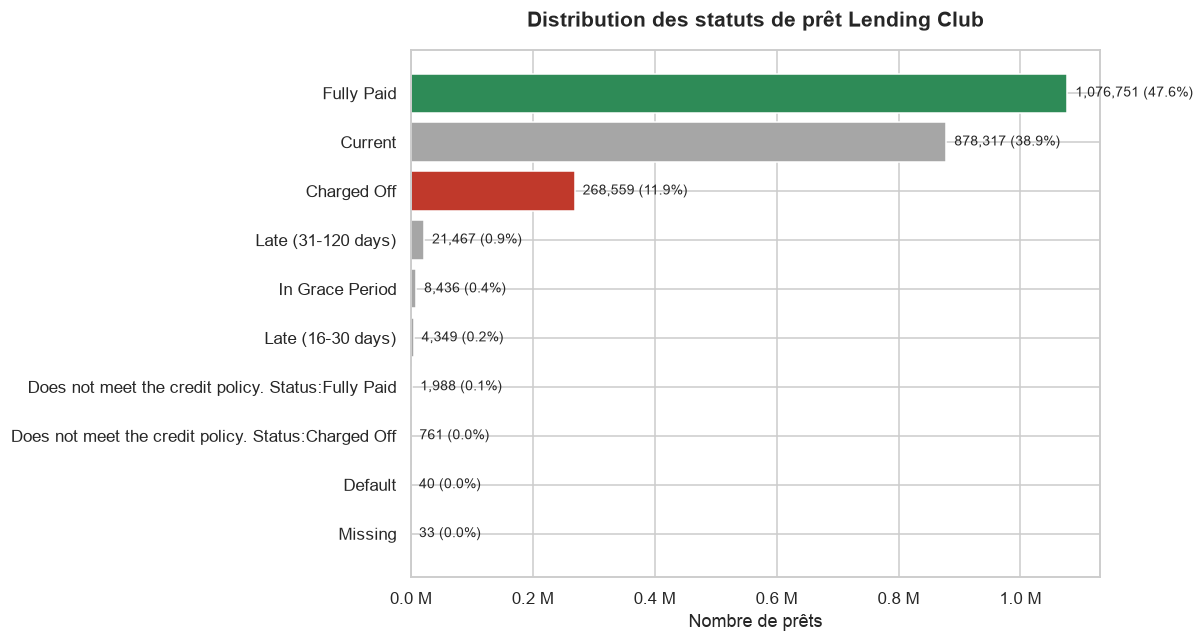

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/loan_status_distribution.png


In [8]:
status_plot_df = status_summary.copy()

status_plot_df["status_label"] = (
    status_plot_df["loan_status"]
    .fillna("Missing")
    .astype(str)
)

status_plot_df = status_plot_df.sort_values(
    "n_loans",
    ascending=True
)

status_colors = np.where(
    status_plot_df["loan_status"].isin(GOOD_STATUSES),
    "#2E8B57",
    np.where(
        status_plot_df["loan_status"].isin(BAD_STATUSES),
        "#C0392B",
        "#A6A6A6"
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    status_plot_df["status_label"],
    status_plot_df["n_loans"],
    color=status_colors
)

for bar, (_, row) in zip(bars, status_plot_df.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {row['n_loans']:,} ({row['share']:.1%})",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Distribution des statuts de prêt Lending Club",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Nombre de prêts")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f} M")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "loan_status_distribution.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


### Interprétation

Les prêts `Fully Paid` et `Charged Off` constituent les deux groupes
principaux dont l'issue finale est connue. Ils formeront la population
d'apprentissage du modèle de PD.

Les prêts `Current`, `Late` ou `In Grace Period` sont exclus : leur statut
final n'est pas connu au moment de l'extraction. Les classer comme des
non-défauts sous-estimerait artificiellement le risque et biaiserait le modèle.

La cible binaire sera définie dans le bloc suivant :

- `Fully Paid` : `default_flag = 0` ;
- `Charged Off` ou `Default` : `default_flag = 1`.


In [9]:
status_summary.to_csv(
    OUTPUT_TABLES_DIR / "loan_status_distribution.csv",
    index=False
)

print(
    "Table exportée : "
    f"{OUTPUT_TABLES_DIR / 'loan_status_distribution.csv'}"
)


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/loan_status_distribution.csv


### Interprétation

Le fichier contient 1 345 350 prêts ayant une issue finale connue :
1 076 751 prêts entièrement remboursés et 268 599 prêts en défaut.

La population de modélisation présente un taux de défaut brut d'environ 20 %.
Elle est déséquilibrée, mais la classe défaut reste suffisamment représentée
pour entraîner et évaluer un modèle de PD robuste.

Les prêts `Current`, en retard ou en période de grâce sont exclus car leur
issue finale est inconnue. Les considérer comme des non-défauts aurait
sous-estimé le risque et introduit un biais de maturité.


## Construction de la table analytique

Nous construisons une table dédiée à la modélisation de la probabilité de
défaut.

Seuls les prêts ayant une issue finale connue sont conservés :

- `Fully Paid` : non-défaut, `default_flag = 0` ;
- `Charged Off` ou `Default` : défaut, `default_flag = 1`.

Les variables sélectionnées sont connues au plus tard à l'octroi. Les variables
de paiement, de recouvrement ou de suivi du prêt sont volontairement absentes
afin d'empêcher toute fuite d'information.


In [10]:
# ============================================================
# 5. CONSTRUCTION DE LA TABLE ANALYTIQUE
# ============================================================

# Identifiant, date et cible brute
IDENTIFIER_COLUMNS = ["id"]
DATE_COLUMNS = ["issue_d"]
TARGET_COLUMNS = ["loan_status"]

# Caractéristiques contractuelles connues à l'octroi
LOAN_FEATURES = [
    "loan_amnt",
    "term",
    "purpose",
    "application_type",
]

# Situation socio-économique déclarée
BORROWER_FEATURES = [
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "dti",
    "addr_state",
]

# Historique de crédit disponible à l'octroi
CREDIT_FEATURES = [
    "earliest_cr_line",
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "acc_open_past_24mths",
    "bc_open_to_buy",
    "bc_util",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "mort_acc",
    "mths_since_recent_bc",
    "mths_since_recent_inq",
    "num_accts_ever_120_pd",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "percent_bc_gt_75",
    "pub_rec_bankruptcies",
    "tax_liens",
    "tot_cur_bal",
    "total_bc_limit",
    "total_rev_hi_lim",
]

# Variables volontairement exclues du modèle principal :
# - int_rate, grade et sub_grade : sorties de la politique de risque Lending Club ;
# - paiements, recouvrements et soldes : informations post-octroi.
EXCLUDED_POLICY_COLUMNS = [
    "int_rate",
    "grade",
    "sub_grade",
]

MODELING_COLUMNS = (
    IDENTIFIER_COLUMNS
    + DATE_COLUMNS
    + TARGET_COLUMNS
    + LOAN_FEATURES
    + BORROWER_FEATURES
    + CREDIT_FEATURES
)

# Vérification contre l'en-tête du fichier, lu dans le bloc précédent
missing_modeling_columns = sorted(
    set(MODELING_COLUMNS) - set(raw_columns)
)

assert not missing_modeling_columns, (
    "Colonnes attendues absentes : "
    f"{missing_modeling_columns}"
)

print(f"Nombre de colonnes lues : {len(MODELING_COLUMNS)}")
print(f"Variables prédictives   : {len(MODELING_COLUMNS) - 3}")
print(f"Variables exclues       : {EXCLUDED_POLICY_COLUMNS}")


Nombre de colonnes lues : 41
Variables prédictives   : 38
Variables exclues       : ['int_rate', 'grade', 'sub_grade']


In [11]:
#Chargement par morceaux
mature_chunks = []

rows_read = 0
rows_kept = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(
        RAW_FILE,
        usecols=MODELING_COLUMNS,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    rows_read += len(chunk)

    # Conservation exclusive des prêts à issue finale connue
    mature_chunk = chunk.loc[
        chunk["loan_status"].isin(MATURE_STATUSES)
    ].copy()

    # Création de la cible de défaut
    mature_chunk["default_flag"] = (
        mature_chunk["loan_status"]
        .isin(BAD_STATUSES)
        .astype("int8")
    )

    rows_kept += len(mature_chunk)
    mature_chunks.append(mature_chunk)

    print(
        f"Chunk {chunk_number:02d} | "
        f"lignes lues : {rows_read:>10,} | "
        f"prêts retenus : {rows_kept:>10,}"
    )

    del chunk, mature_chunk
    gc.collect()

modeling_df = pd.concat(mature_chunks, ignore_index=True)

del mature_chunks
gc.collect()

print("\n" + "=" * 64)
print("CHARGEMENT TERMINÉ")
print("=" * 64)
print(f"Prêts bruts lus                : {rows_read:,}")
print(f"Prêts à issue finale conservés : {len(modeling_df):,}")
print(f"Part conservée                 : {len(modeling_df) / rows_read:.2%}")
print(f"Dimensions de modeling_df      : {modeling_df.shape}")


Chunk 01 | lignes lues :    200,000 | prêts retenus :    176,083
Chunk 02 | lignes lues :    400,000 | prêts retenus :    356,181
Chunk 03 | lignes lues :    600,000 | prêts retenus :    422,382
Chunk 04 | lignes lues :    800,000 | prêts retenus :    508,120
Chunk 05 | lignes lues :  1,000,000 | prêts retenus :    571,494
Chunk 06 | lignes lues :  1,200,000 | prêts retenus :    748,291
Chunk 07 | lignes lues :  1,400,000 | prêts retenus :    896,197
Chunk 08 | lignes lues :  1,600,000 | prêts retenus :    916,209
Chunk 09 | lignes lues :  1,800,000 | prêts retenus :  1,053,648
Chunk 10 | lignes lues :  2,000,000 | prêts retenus :  1,229,863
Chunk 11 | lignes lues :  2,200,000 | prêts retenus :  1,310,943
Chunk 12 | lignes lues :  2,260,701 | prêts retenus :  1,345,350

CHARGEMENT TERMINÉ
Prêts bruts lus                : 2,260,701
Prêts à issue finale conservés : 1,345,350
Part conservée                 : 59.51%
Dimensions de modeling_df      : (1345350, 42)


In [12]:
#Controle qualité
# Contrôles de cohérence de la table analytique

assert modeling_df["default_flag"].isin([0, 1]).all(), (
    "default_flag doit contenir exclusivement 0 et 1."
)

assert modeling_df["loan_status"].isin(MATURE_STATUSES).all(), (
    "Un statut non mature est présent dans modeling_df."
)

assert modeling_df["id"].notna().all(), (
    "Des identifiants de prêt sont manquants."
)

duplicate_loan_ids = modeling_df["id"].duplicated().sum()

print(f"Nombre de lignes       : {len(modeling_df):,}")
print(f"Nombre de colonnes     : {modeling_df.shape[1]:,}")
print(f"Identifiants dupliqués : {duplicate_loan_ids:,}")
print(f"Taux de défaut         : {modeling_df['default_flag'].mean():.2%}")

assert duplicate_loan_ids == 0, (
    "Des prêts dupliqués ont été détectés."
)


Nombre de lignes       : 1,345,350
Nombre de colonnes     : 42
Identifiants dupliqués : 0
Taux de défaut         : 19.96%


In [13]:
#Cible finale
target_summary = (
    modeling_df
    .groupby(["loan_status", "default_flag"], observed=True)
    .size()
    .reset_index(name="n_loans")
)

target_summary["share"] = (
    target_summary["n_loans"] / target_summary["n_loans"].sum()
)

target_summary["n_loans"] = target_summary["n_loans"].astype("int64")

display(target_summary)


,loan_status,default_flag,n_loans,share
0,Charged Off,1,268559,0.1996
1,Default,1,40,0.0000
2,Fully Paid,0,1076751,0.8004


### Contrôle de la table analytique

La table analytique contient uniquement les prêts dont l'issue finale est
connue et une cible binaire cohérente avec le statut observé.

Les identifiants de prêt sont uniques, ce qui confirme que l'unité
d'observation est bien un prêt. Le taux de défaut de cette population constitue
la référence non conditionnelle que les modèles devront dépasser en matière de
discrimination et de calibration.


### Interprétation

La cible binaire est cohérente avec la règle de gestion définie :

- `Fully Paid` est codé comme non-défaut (`default_flag = 0`) ;
- `Charged Off` et `Default` sont codés comme défaut (`default_flag = 1`).

La population analytique contient 1 345 350 prêts, dont environ 20 % de défauts.
La classe défaut est minoritaire mais reste largement représentée, ce qui rend
possible l'entraînement et l'évaluation de modèles de PD sans recourir
automatiquement à du sur-échantillonnage.

L'accuracy ne sera pas une métrique principale : les futurs modèles seront
évalués selon leur discrimination (ROC-AUC, Gini, KS, AUC-PR) et leur
calibration probabiliste.


## Analyse temporelle des cohortes

La date d'octroi `issue_d` permet d'analyser les prêts par millésime et de
construire ultérieurement un split train / validation / test strictement
chronologique.

Avant de fixer les périodes, nous vérifions la qualité de la variable date,
le volume de prêts par année et l'évolution du taux de défaut observé.


In [14]:
# ============================================================
# 6. PRÉPARATION DE LA DIMENSION TEMPORELLE
# ============================================================

DATE_COLUMN = "issue_d"

# Format original observé : "Dec-2015"
modeling_df[DATE_COLUMN] = pd.to_datetime(
    modeling_df[DATE_COLUMN],
    format="%b-%Y",
    errors="coerce"
)

date_quality = pd.DataFrame(
    {
        "metric": [
            "Nombre de prêts",
            "Dates manquantes ou invalides",
            "Part de dates manquantes",
            "Date minimale",
            "Date maximale",
        ],
        "value": [
            f"{len(modeling_df):,}",
            f"{modeling_df[DATE_COLUMN].isna().sum():,}",
            f"{modeling_df[DATE_COLUMN].isna().mean():.2%}",
            modeling_df[DATE_COLUMN].min().strftime("%Y-%m-%d"),
            modeling_df[DATE_COLUMN].max().strftime("%Y-%m-%d"),
        ],
    }
)

display(date_quality)

# Une date manquante empêche l'analyse temporelle et le split ultérieur.
rows_before_date_filter = len(modeling_df)

modeling_df = modeling_df.dropna(
    subset=[DATE_COLUMN]
).copy()

print(
    "Prêts retirés pour date absente ou invalide : "
    f"{rows_before_date_filter - len(modeling_df):,}"
)
print(f"Prêts restant après contrôle date : {len(modeling_df):,}")


,metric,value
0,Nombre de prêts,"1,345,350"
1,Dates manquantes ou invalides,0
2,Part de dates manquantes,0.00%
3,Date minimale,2007-06-01
4,Date maximale,2018-12-01


Prêts retirés pour date absente ou invalide : 0
Prêts restant après contrôle date : 1,345,350


In [15]:
#Tableau par millésime
modeling_df["issue_year"] = modeling_df[DATE_COLUMN].dt.year

vintage_summary = (
    modeling_df
    .groupby("issue_year", observed=True)
    .agg(
        n_loans=("id", "size"),
        n_defaults=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        mean_loan_amount=("loan_amnt", "mean"),
    )
    .reset_index()
)

vintage_summary["share_loans"] = (
    vintage_summary["n_loans"]
    / vintage_summary["n_loans"].sum()
)

display(vintage_summary)

vintage_summary.to_csv(
    OUTPUT_TABLES_DIR / "vintage_summary.csv",
    index=False
)

print(
    "Table exportée : "
    f"{OUTPUT_TABLES_DIR / 'vintage_summary.csv'}"
)


,issue_year,n_loans,n_defaults,default_rate,mean_loan_amount,share_loans
0,2007,251,45,0.1793,"8,841.7331",0.0002
1,2008,1562,247,0.1581,"9,212.7241",0.0012
2,2009,4716,594,0.1260,"9,846.5490",0.0035
3,2010,11536,1487,0.1289,"10,586.0957",0.0086
4,2011,21721,3297,0.1518,"12,047.5036",0.0161
5,2012,53367,8644,0.1620,"13,461.7090",0.0397
6,2013,134804,21024,0.1560,"14,707.3752",0.1002
7,2014,223103,41162,0.1845,"14,582.9034",0.1658
8,2015,375546,75804,0.2019,"14,641.6182",0.2791
9,2016,293105,68252,0.2329,"14,467.0395",0.2179


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/vintage_summary.csv


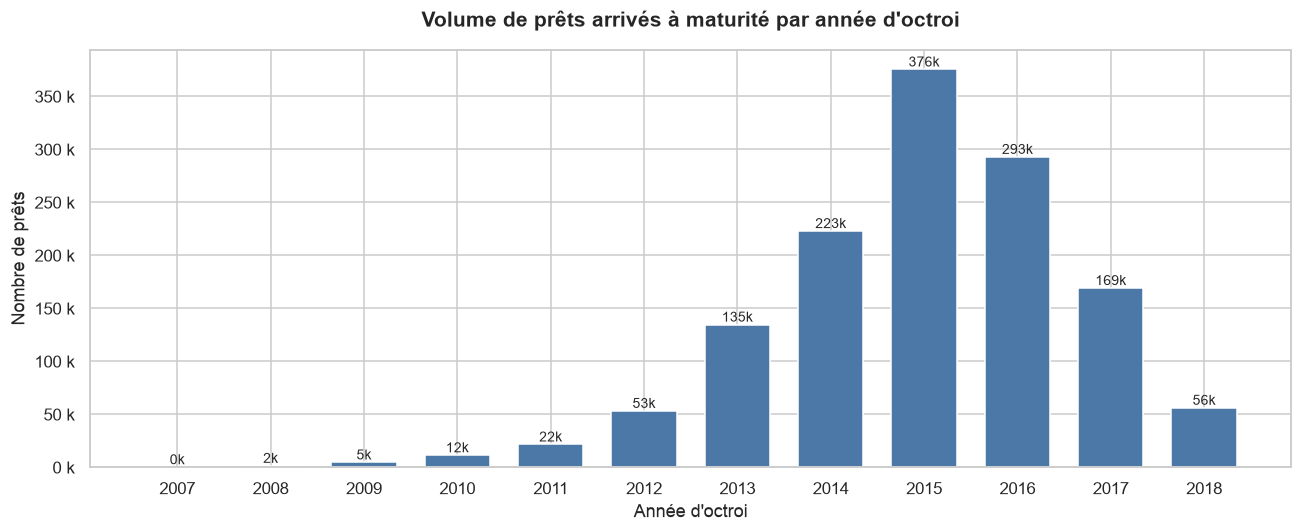

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/loan_volume_by_vintage.png


In [16]:
#Graphique 1 — Volume par millésime
#Pourquoi ce graphique ?
#Il montre la croissance ou la contraction du portefeuille Lending Club et permet de vérifier que chaque future période du split disposera de suffisamment de prêts.
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    vintage_summary["issue_year"].astype(str),
    vintage_summary["n_loans"],
    color="#4C78A8",
    width=0.7
)

for bar, (_, row) in zip(bars, vintage_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['n_loans'] / 1_000:.0f}k",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Volume de prêts arrivés à maturité par année d'octroi",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Année d'octroi")
ax.set_ylabel("Nombre de prêts")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f} k")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "loan_volume_by_vintage.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


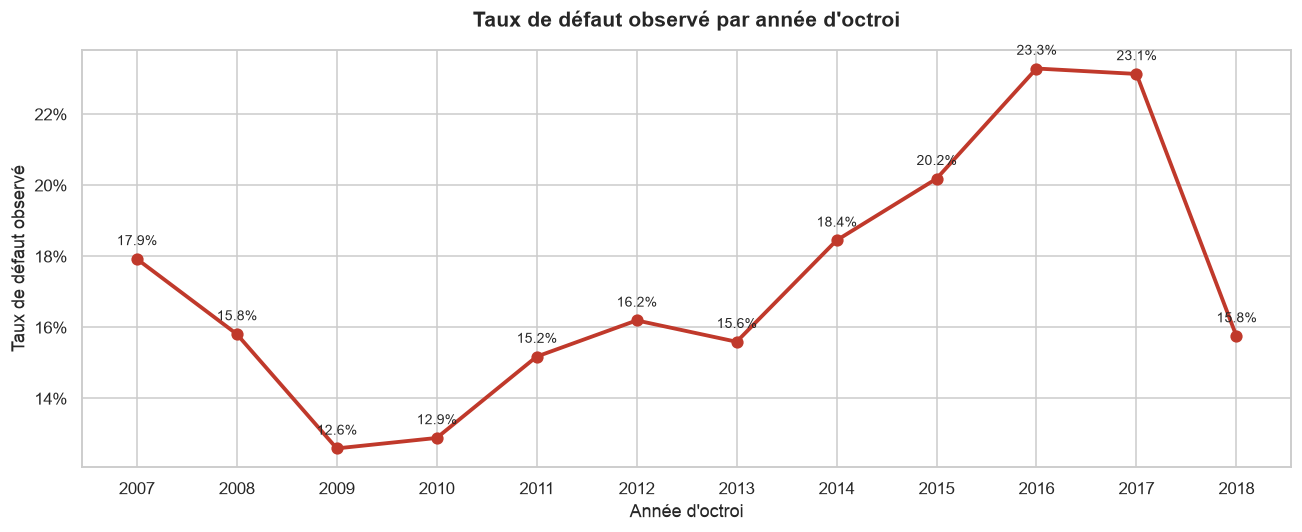

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/default_rate_by_vintage.png


In [17]:
#Graphique 2 — Taux de défaut par millésime
#Pourquoi ce graphique ?
#Il révèle une éventuelle dérive temporelle du risque. Si le taux de défaut varie fortement entre années, un split aléatoire serait inadapté car il mélangerait des environnements de risque différents.

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    vintage_summary["issue_year"],
    vintage_summary["default_rate"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#C0392B"
)

for _, row in vintage_summary.iterrows():
    ax.annotate(
        f"{row['default_rate']:.1%}",
        (row["issue_year"], row["default_rate"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Taux de défaut observé par année d'octroi",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Année d'octroi")
ax.set_ylabel("Taux de défaut observé")
ax.set_xticks(vintage_summary["issue_year"])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "default_rate_by_vintage.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


### Interprétation

Les millésimes présentent des volumes et des taux de défaut différents selon
l'année d'octroi. Cette évolution indique que le portefeuille n'est pas
parfaitement stationnaire dans le temps.

Un split aléatoire mélangerait les prêts anciens et récents, ce qui fournirait
une estimation trop optimiste de la performance future. Le projet utilisera
donc une validation strictement chronologique.

La période de test finale devra être choisie avec prudence : les cohortes
récentes peuvent être incomplètement observées, notamment pour les prêts de
60 mois. Un diagnostic de maturité sera réalisé avant de figer le split.


L’analyse confirme une forte dérive temporelle du portefeuille. Le taux de défaut baisse à 12,6–12,9% en 2009–2010, puis augmente jusqu’à 23,3% en 2016 et 23,1% en 2017 ; un split aléatoire serait donc trompeur.
Lecture des cohortes
Le portefeuille croît très fortement de 2012 à 2015, puis se contracte : il passe de 53 365 prêts en 2012 à 375 546 en 2015, avant de retomber à 56 318 en 2018. Cette baisse sur les années récentes ne signifie pas forcément une baisse des octrois ; elle reflète surtout le fait que nous ne conservons que les prêts ayant déjà une issue finale connue.[Pièce jointe +1]
La hausse du risque est nette : 15,6% de défaut en 2013, 18,4% en 2014, 20,2% en 2015 et plus de 23% en 2016–2017. Le test final doit donc être postérieur à l’entraînement, avec un niveau de risque plus exigeant, afin de tester la robustesse réelle du score.[Pièce jointe +1]
La baisse à 15,8% en 2018 est suspecte : ces prêts ont été observés moins longtemps, donc seuls ceux dont l’issue s’est déjà résolue sont présents. C’est un signe de censure temporelle et non une preuve d’amélioration de la qualité de crédit.[Pièce jointe +1]

### Interprétation

Les volumes et les taux de défaut varient fortement selon le millésime
d'octroi. Le portefeuille atteint son volume maximal en 2015, avec environ
375 000 prêts arrivés à maturité.

Le taux de défaut passe d'environ 12,6 % en 2009 à plus de 23 % en 2016 et
2017. Cette évolution confirme une dérive temporelle du risque : les cohortes
récentes ne présentent pas le même environnement de crédit que les cohortes
anciennes.

La baisse apparente du défaut en 2018 doit être interprétée avec prudence.
Les prêts récents disposent d'une durée d'observation plus courte et les prêts
encore actifs ont été exclus. La population 2018 retenue n'est donc pas
représentative de l'ensemble des prêts octroyés cette année-là.

Le projet utilisera un split strictement chronologique. Avant de le fixer,
nous vérifierons la maturité des cohortes selon la durée contractuelle des
prêts, 36 ou 60 mois.


## Diagnostic de maturité des cohortes

Les prêts dont le statut est finalisé (`Fully Paid` ou `Charged Off`) ne sont
pas forcément représentatifs de tous les prêts récemment octroyés : certains
prêts restent encore actifs au moment de l'extraction.

Nous mesurons donc la proportion de prêts ayant théoriquement dépassé leur
durée contractuelle à la date de référence du 31 mars 2019.

Cette analyse est réalisée par année d'octroi et par durée de prêt (`36 months`
ou `60 months`) afin d'identifier les cohortes qui peuvent être utilisées sans
fort biais de censure temporelle.


In [18]:
# ============================================================
# 7. DIAGNOSTIC DE MATURITÉ DES COHORTES
# ============================================================

OBSERVATION_CUTOFF_DATE = pd.Timestamp("2019-03-31")

# Extraire la durée : " 36 months" devient 36
modeling_df["term_months"] = (
    modeling_df["term"]
    .str.extract(r"(\d+)", expand=False)
    .astype("Int64")
)

# Échéance théorique :
# Date d'octroi + durée du contrat exprimée en mois.
modeling_df["contractual_end_date"] = (
    modeling_df[DATE_COLUMN]
    + pd.DateOffset(months=0)  # Initialise une série de dates
)

# DateOffset ne s'applique pas directement à une durée variable par ligne.
# La conversion en jours utilise la durée moyenne d'un mois : 365.25 / 12.
modeling_df["contractual_end_date"] = (
    modeling_df[DATE_COLUMN]
    + pd.to_timedelta(
        modeling_df["term_months"].astype(float) * (365.25 / 12),
        unit="D"
    )
)

modeling_df["contractually_mature"] = (
    modeling_df["contractual_end_date"]
    <= OBSERVATION_CUTOFF_DATE
)

maturity_summary = (
    modeling_df
    .groupby(["issue_year", "term_months"], observed=True)
    .agg(
        n_loans=("id", "size"),
        n_contractually_mature=("contractually_mature", "sum"),
        maturity_rate=("contractually_mature", "mean"),
    )
    .reset_index()
    .sort_values(["issue_year", "term_months"])
)

maturity_summary["n_not_mature"] = (
    maturity_summary["n_loans"]
    - maturity_summary["n_contractually_mature"]
)

maturity_summary["term_label"] = (
    maturity_summary["term_months"].astype(str)
    + " months"
)

display(maturity_summary)


,issue_year,term_months,n_loans,n_contractually_mature,maturity_rate,n_not_mature,term_label
0,2007,36,251,251,1.0000,0,36 months
1,2008,36,1562,1562,1.0000,0,36 months
2,2009,36,4716,4716,1.0000,0,36 months
3,2010,36,8466,8466,1.0000,0,36 months
4,2010,60,3070,3070,1.0000,0,60 months
5,2011,36,14101,14101,1.0000,0,36 months
6,2011,60,7620,7620,1.0000,0,60 months
7,2012,36,43470,43470,1.0000,0,36 months
8,2012,60,9897,9897,1.0000,0,60 months
9,2013,36,100422,100422,1.0000,0,36 months


In [19]:
maturity_summary.to_csv(
    OUTPUT_TABLES_DIR / "maturity_by_vintage_and_term.csv",
    index=False
)

print(
    "Table exportée : "
    f"{OUTPUT_TABLES_DIR / 'maturity_by_vintage_and_term.csv'}"
)


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/maturity_by_vintage_and_term.csv


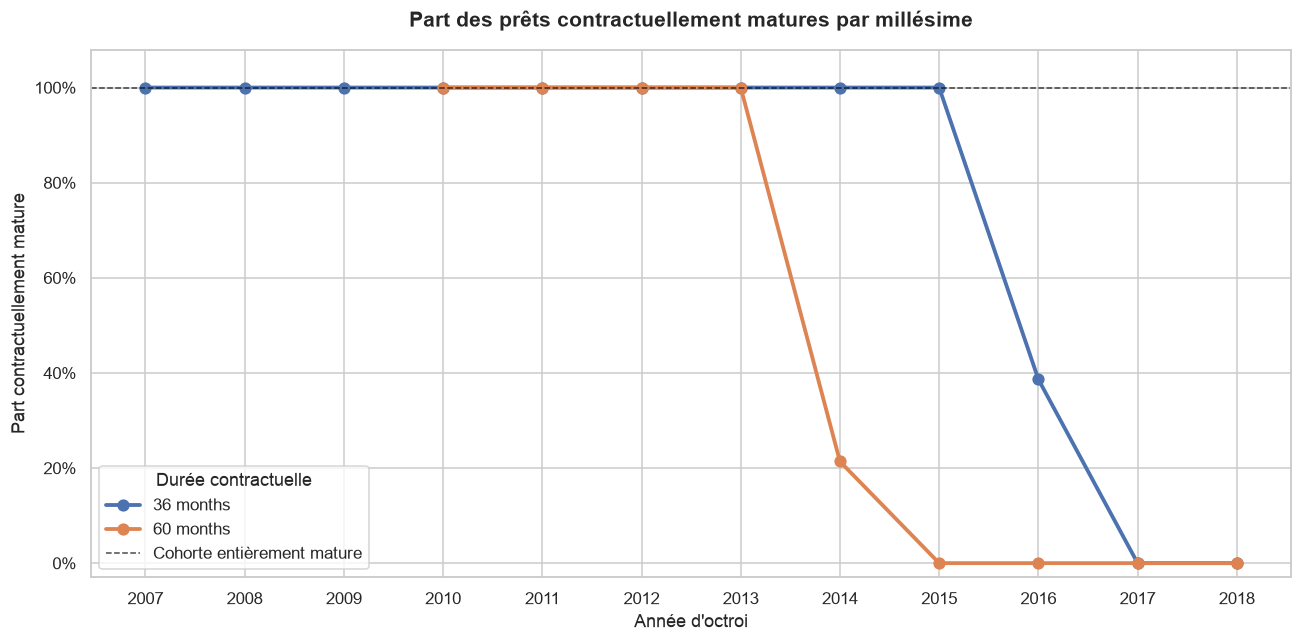

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/maturity_rate_by_vintage_and_term.png


In [20]:
#Graphique — Maturité par millésime

#Pourquoi ce graphique ?
#•	100% signifie que toute la cohorte a, théoriquement, dépassé la durée du prêt.
#•	Une valeur faible indique une cohorte récente : le défaut final est encore partiellement inconnu.
#•	La comparaison 36 vs 60 mois montre clairement pourquoi les prêts longs doivent être traités avec davantage de prudence.

fig, ax = plt.subplots(figsize=(12, 6))

for term_months, term_data in maturity_summary.groupby(
    "term_months",
    observed=True
):
    ax.plot(
        term_data["issue_year"],
        term_data["maturity_rate"],
        marker="o",
        markersize=7,
        linewidth=2.5,
        label=f"{int(term_months)} months"
    )

ax.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Cohorte entièrement mature"
)

ax.set_title(
    "Part des prêts contractuellement matures par millésime",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Année d'octroi")
ax.set_ylabel("Part contractuellement mature")
ax.set_xticks(sorted(maturity_summary["issue_year"].unique()))
ax.set_ylim(-0.03, 1.08)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend(
    title="Durée contractuelle",
    loc="lower left",
    frameon=True
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "maturity_rate_by_vintage_and_term.png"
)

plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


### Interprétation

Une cohorte est dite contractuellement mature lorsque sa durée de prêt est
entièrement écoulée à la date de référence de l'extraction.

Les cohortes anciennes ont une maturité proche de 100 %. À l'inverse, les
cohortes récentes, surtout pour les prêts de 60 mois, sont incomplètement
observées : leurs défauts futurs ne sont pas tous visibles.

La période de test finale sera donc choisie parmi les cohortes entièrement
matures. Cette décision réduit le volume disponible, mais rend l'évaluation
du modèle de PD beaucoup plus crédible et robuste.


### Décision méthodologique

Le diagnostic montre que les prêts à 36 mois sont entièrement matures jusqu'au
millésime 2015, tandis que les prêts à 60 mois ne sont entièrement matures que
jusqu'en 2013.

La V1 du modèle est donc limitée aux prêts de 36 mois octroyés entre 2007 et
2015 inclus. Cette restriction garantit que chaque prêt retenu a disposé d'un
horizon d'observation au moins égal à sa durée contractuelle.

Le split temporel final sera :

- entraînement : 2007 à 2013 ;
- validation : 2014 ;
- test final hors échantillon : 2015.

Les prêts de 60 mois et les cohortes postérieures à 2015 sont exclus de cette
V1 afin d'éviter un biais de censure temporelle. Cette décision réduit le
volume de données, mais renforce la validité des métriques de discrimination et
de calibration.


## Population finale et split temporel

Le diagnostic de maturité confirme que les prêts de 36 mois octroyés entre
2007 et 2015 ont tous dépassé leur horizon contractuel à la date d'observation.

La population finale de la V1 est donc limitée à ces prêts. Le découpage est
strictement temporel :

- train : 2007 à 2013 ;
- validation : 2014 ;
- test final : 2015.

Les prêts de 60 mois et les cohortes postérieures à 2015 sont exclus afin
d'éviter la censure temporelle et de maintenir une population homogène.


In [21]:
# ============================================================
# 8. POPULATION FINALE ET SPLIT TEMPOREL
# ============================================================

FINAL_TERM_MONTHS = 36

TRAIN_END_DATE = pd.Timestamp("2013-12-31")
VALIDATION_END_DATE = pd.Timestamp("2014-12-31")
TEST_END_DATE = pd.Timestamp("2015-12-31")

final_modeling_df = modeling_df.loc[
    (modeling_df["term_months"] == FINAL_TERM_MONTHS)
    & (modeling_df[DATE_COLUMN] <= TEST_END_DATE)
].copy()

print(f"Prêts matures avant filtrage : {len(modeling_df):,}")
print(f"Prêts retenus pour la V1     : {len(final_modeling_df):,}")
print(
    "Part de la population conservée : "
    f"{len(final_modeling_df) / len(modeling_df):.2%}"
)

assert final_modeling_df["term_months"].eq(FINAL_TERM_MONTHS).all(), (
    "Erreur : prêts hors durée 36 mois détectés."
)

assert final_modeling_df[DATE_COLUMN].le(TEST_END_DATE).all(), (
    "Erreur : prêts postérieurs à décembre 2015 détectés."
)


Prêts matures avant filtrage : 1,345,350
Prêts retenus pour la V1     : 618,584
Part de la population conservée : 45.98%


In [22]:
#Attribution des jeux
final_modeling_df["dataset_split"] = np.select(
    [
        final_modeling_df[DATE_COLUMN] <= TRAIN_END_DATE,
        final_modeling_df[DATE_COLUMN] <= VALIDATION_END_DATE,
    ],
    [
        "train",
        "validation",
    ],
    default="test"
)

SPLIT_ORDER = ["train", "validation", "test"]

final_split_summary = (
    final_modeling_df
    .groupby("dataset_split", observed=True)
    .agg(
        start_date=(DATE_COLUMN, "min"),
        end_date=(DATE_COLUMN, "max"),
        n_loans=("id", "size"),
        n_defaults=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        mean_loan_amount=("loan_amnt", "mean"),
    )
    .reindex(SPLIT_ORDER)
    .reset_index()
)

final_split_summary["share_loans"] = (
    final_split_summary["n_loans"]
    / final_split_summary["n_loans"].sum()
)

final_split_summary["start_date"] = (
    final_split_summary["start_date"].dt.strftime("%Y-%m")
)

final_split_summary["end_date"] = (
    final_split_summary["end_date"].dt.strftime("%Y-%m")
)

display(final_split_summary)


,dataset_split,start_date,end_date,n_loans,n_defaults,default_rate,mean_loan_amount,share_loans
0,train,2007-06,2013-12,172988,21508,0.1243,"11,902.5983",0.2797
1,validation,2014-01,2014-12,162570,22315,0.1373,"12,585.5985",0.2628
2,test,2015-01,2015-12,283026,42132,0.1489,"12,805.5401",0.4575


In [23]:
# Contrôles d'absence de chevauchement des périodes

train_max_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "train",
    DATE_COLUMN
].max()

validation_min_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "validation",
    DATE_COLUMN
].min()

validation_max_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "validation",
    DATE_COLUMN
].max()

test_min_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "test",
    DATE_COLUMN
].min()

assert train_max_date <= TRAIN_END_DATE
assert validation_min_date > TRAIN_END_DATE
assert validation_max_date <= VALIDATION_END_DATE
assert test_min_date > VALIDATION_END_DATE
assert final_modeling_df["dataset_split"].isin(SPLIT_ORDER).all()

print("Contrôles temporels : OK")
print(f"Fin train         : {train_max_date:%Y-%m}")
print(f"Début validation  : {validation_min_date:%Y-%m}")
print(f"Fin validation    : {validation_max_date:%Y-%m}")
print(f"Début test        : {test_min_date:%Y-%m}")


Contrôles temporels : OK
Fin train         : 2013-12
Début validation  : 2014-01
Fin validation    : 2014-12
Début test        : 2015-01


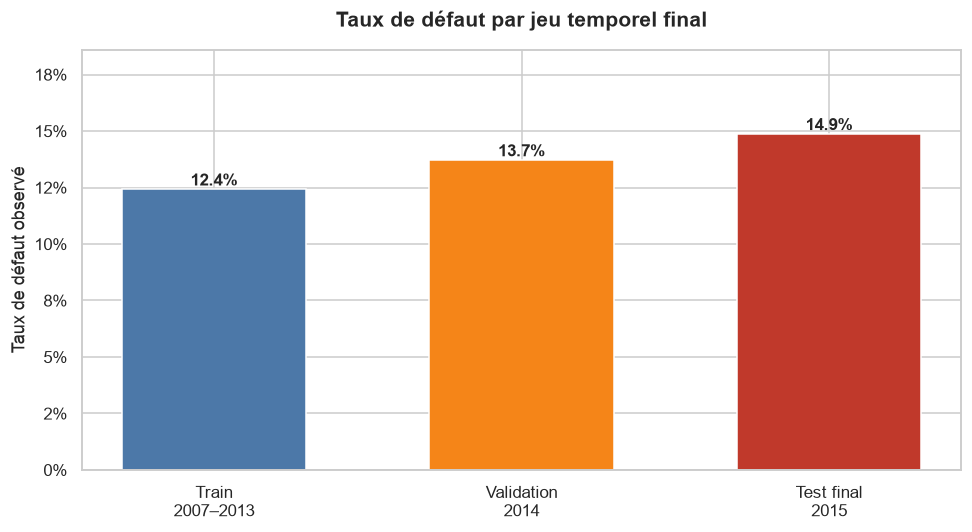

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/default_rate_by_final_split.png


In [24]:
#Graphique — Taux de défaut par jeu
#Pourquoi ce graphique ?
#Il met en évidence la dérive du risque entre les trois périodes. Ce n’est pas un résultat du modèle, mais un diagnostic important : une hausse de défaut sur validation ou test rend l’évaluation plus réaliste et plus exigeante.
split_plot_df = final_split_summary.copy()

split_plot_df["dataset_label"] = split_plot_df["dataset_split"].map({
    "train": "Train\n2007–2013",
    "validation": "Validation\n2014",
    "test": "Test final\n2015",
})

split_colors = {
    "train": "#4C78A8",
    "validation": "#F58518",
    "test": "#C0392B",
}

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    split_plot_df["dataset_label"],
    split_plot_df["default_rate"],
    color=[
        split_colors[split_name]
        for split_name in split_plot_df["dataset_split"]
    ],
    width=0.6
)

for bar, (_, row) in zip(bars, split_plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['default_rate']:.1%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Taux de défaut par jeu temporel final",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("")
ax.set_ylabel("Taux de défaut observé")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
ax.set_ylim(0, split_plot_df["default_rate"].max() * 1.25)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "default_rate_by_final_split.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")



Le split final est cohérent et très solide pour la suite : il est strictement chronologique, les trois jeux sont volumineux, et le taux de défaut augmente progressivement de 12,4% à 14,9%. Cela crée une évaluation réaliste de la capacité du modèle à généraliser sur un portefeuille futur plus risqué.

Le dataset final contient donc 618 584 prêts, dont 85 955 défauts. Les tailles sont largement suffisantes pour entraîner une scorecard logistique et un modèle XGBoost, y compris pour évaluer les métriques par décile et les courbes de calibration.[Pièce jointe]
Dérive du risque
Le taux de défaut augmente de 1,30 point entre train et validation, puis de 2,46 points entre train et test. Cette hausse montre que le test 2015 est plus exigeant que l’entraînement, ce qui est précisément ce que l’on recherche dans une validation temporelle crédible.[Pièce jointe +1]
Le montant moyen de prêt augmente aussi au fil du temps : environ 11 903 dollars en train, 12 586 dollars en validation et 12 806 dollars en test. Cette évolution suggère que la dérive ne touche pas seulement le taux de défaut, mais également la structure du portefeuille.[Pièce jointe]
Implication pour les modèles
•	La validation 2014 servira à sélectionner les variables, régler XGBoost et choisir une méthode de calibration.
•	Le test 2015 restera intact jusqu’à l’évaluation finale ; il ne doit jamais guider les choix de paramétrage.
•	Le modèle devra être jugé autant sur sa discrimination que sur sa calibration : une PD bien classée mais systématiquement trop basse serait dangereuse dans un contexte de crédit.
•	Les métriques finales seront ROC-AUC, Gini, KS, AUC-PR, Brier score et courbes de calibration.








### Interprétation

La population finale contient 618 584 prêts de 36 mois, répartis selon un
split strictement chronologique entre entraînement, validation et test final.

Le taux de défaut augmente progressivement de 12,4 % dans le train à 13,7 %
en validation, puis à 14,9 % dans le test final. Le portefeuille de test est
donc plus risqué que les données utilisées pour entraîner le modèle.

Cette dérive temporelle rend l'évaluation plus réaliste : le modèle devra
généraliser sur une cohorte future dont le profil de risque diffère de celui
observé durant l'entraînement.

La validation 2014 sera utilisée pour sélectionner et régler les modèles.
Le test 2015 restera réservé à l'évaluation finale, après le gel des choix
méthodologiques.


### Interprétation

Le split final est strictement chronologique et ne comporte aucun chevauchement
entre les périodes.

Les jeux de validation et de test correspondent à des cohortes futures par
rapport aux données d'entraînement. Leurs taux de défaut peuvent différer de
celui du train : cette variation représente une dérive réaliste du portefeuille
et constitue un test exigeant de la capacité de généralisation des modèles.

Les métriques de performance seront d'abord utilisées pour choisir les modèles
sur la validation 2014, puis reportées une seule fois sur le test final 2015.


In [25]:
final_split_summary.to_csv(
    OUTPUT_TABLES_DIR / "final_temporal_split_summary.csv",
    index=False
)

print(
    "Table exportée : "
    f"{OUTPUT_TABLES_DIR / 'final_temporal_split_summary.csv'}"
)


Table exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/final_temporal_split_summary.csv


## Contrôle qualité des variables

Avant de préparer les variables pour les modèles, nous réalisons un audit de
qualité sur la population finale.

Cet audit vérifie :

- les types de données ;
- les valeurs manquantes ;
- les variables constantes ou quasi inutilisables ;
- les distributions des principales variables numériques ;
- la stabilité des taux de valeurs manquantes entre train, validation et test.

Aucune imputation ni normalisation n'est appliquée à cette étape. Les règles de
prétraitement seront définies à partir du jeu train uniquement dans les
notebooks de modélisation, afin d'éviter toute fuite d'information.


In [26]:
# ============================================================
# 9. CONTRÔLE QUALITÉ DES VARIABLES
# ============================================================

# Variables non utilisées comme prédicteurs
METADATA_COLUMNS = [
    "id",
    "issue_d",
    "issue_year",
    "loan_status",
    "default_flag",
    "dataset_split",
    "term_months",
    "contractual_end_date",
    "contractually_mature",
]

# `term` est constante dans la population finale :
# tous les prêts retenus sont des prêts de 36 mois.
CONSTANT_BY_DESIGN_COLUMNS = [
    "term",
]

FEATURE_COLUMNS = [
    column
    for column in final_modeling_df.columns
    if column not in METADATA_COLUMNS + CONSTANT_BY_DESIGN_COLUMNS
]

NUMERICAL_FEATURES = [
    column
    for column in FEATURE_COLUMNS
    if pd.api.types.is_numeric_dtype(final_modeling_df[column])
]

CATEGORICAL_FEATURES = [
    column
    for column in FEATURE_COLUMNS
    if column not in NUMERICAL_FEATURES
]

print(f"Variables candidates au modèle : {len(FEATURE_COLUMNS)}")
print(f"Variables numériques            : {len(NUMERICAL_FEATURES)}")
print(f"Variables catégorielles         : {len(CATEGORICAL_FEATURES)}")

print("\nVariables numériques :")
print(NUMERICAL_FEATURES)

print("\nVariables catégorielles :")
print(CATEGORICAL_FEATURES)


Variables candidates au modèle : 37
Variables numériques            : 30
Variables catégorielles         : 7

Variables numériques :
['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'total_bc_limit']

Variables catégorielles :
['emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'earliest_cr_line', 'application_type']


In [27]:
quality_overview = pd.DataFrame(
    {
        "variable": FEATURE_COLUMNS,
        "dtype": [
            str(final_modeling_df[column].dtype)
            for column in FEATURE_COLUMNS
        ],
        "n_missing": [
            final_modeling_df[column].isna().sum()
            for column in FEATURE_COLUMNS
        ],
        "missing_rate": [
            final_modeling_df[column].isna().mean()
            for column in FEATURE_COLUMNS
        ],
        "n_unique": [
            final_modeling_df[column].nunique(dropna=True)
            for column in FEATURE_COLUMNS
        ],
    }
)

quality_overview["variable_type"] = np.where(
    quality_overview["variable"].isin(NUMERICAL_FEATURES),
    "Numerical",
    "Categorical"
)

quality_overview = quality_overview.sort_values(
    ["missing_rate", "n_unique"],
    ascending=[False, False]
).reset_index(drop=True)

display(quality_overview)


,variable,dtype,n_missing,missing_rate,n_unique,variable_type
0,mths_since_recent_inq,float64,97955,0.1584,26,Numerical
1,tot_cur_bal,float64,51646,0.0835,258756,Numerical
2,total_rev_hi_lim,float64,51646,0.0835,16414,Numerical
3,num_accts_ever_120_pd,float64,51646,0.0835,35,Numerical
4,num_tl_90g_dpd_24m,float64,51646,0.0835,23,Numerical
5,num_tl_30dpd,float64,51646,0.0835,5,Numerical
6,bc_util,float64,41324,0.0668,1347,Numerical
7,percent_bc_gt_75,float64,41291,0.0668,207,Numerical
8,bc_open_to_buy,float64,40937,0.0662,55357,Numerical
9,mths_since_recent_bc,float64,40526,0.0655,440,Numerical


In [28]:
#Colonnes constantes
constant_columns = quality_overview.loc[
    quality_overview["n_unique"] <= 1,
    "variable"
].tolist()

print(f"Nombre de variables constantes : {len(constant_columns)}")
print("Variables constantes :", constant_columns)

assert "term" not in FEATURE_COLUMNS, (
    "`term` doit être exclue : elle est constante dans la population finale."
)


Nombre de variables constantes : 0
Variables constantes : []


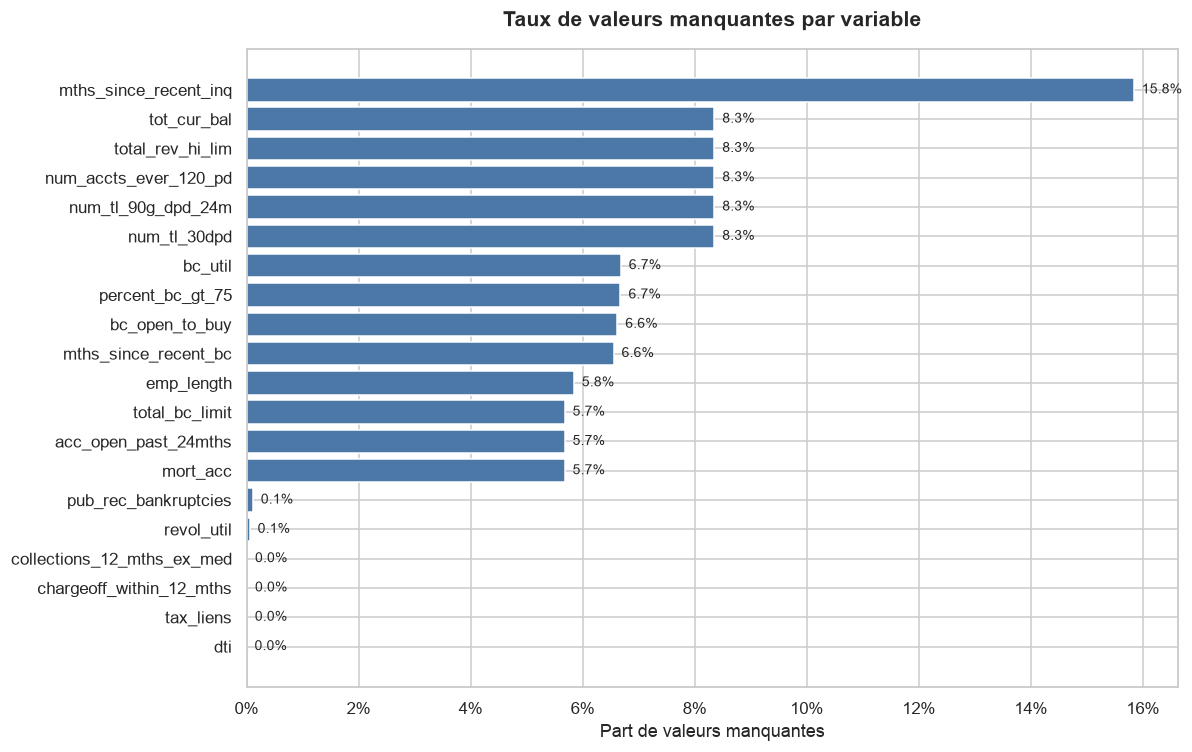

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/missing_rate_by_feature.png


In [29]:
#Graphique — Données manquantes
missing_plot_df = (
    quality_overview
    .loc[quality_overview["missing_rate"] > 0]
    .sort_values("missing_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    missing_plot_df["variable"],
    missing_plot_df["missing_rate"],
    color="#4C78A8"
)

for bar, (_, row) in zip(bars, missing_plot_df.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {row['missing_rate']:.1%}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Taux de valeurs manquantes par variable",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Part de valeurs manquantes")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "missing_rate_by_feature.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figure exportée : {figure_path}")


In [30]:
#Stabilité par période
#Pourquoi ce tableau ?
#Une variable peut être bien renseignée dans le train mais presque absente dans le test. C’est un risque de dérive de données, qui fragilise le modèle en production.
missing_by_split = (
    final_modeling_df
    .groupby("dataset_split", observed=True)[FEATURE_COLUMNS]
    .apply(lambda dataframe: dataframe.isna().mean())
    .T
    .reindex(columns=SPLIT_ORDER)
    .reset_index(names="variable")
)

missing_by_split["max_missing_rate"] = (
    missing_by_split[SPLIT_ORDER].max(axis=1)
)

missing_by_split["missing_rate_range"] = (
    missing_by_split[SPLIT_ORDER].max(axis=1)
    - missing_by_split[SPLIT_ORDER].min(axis=1)
)

missing_by_split = missing_by_split.sort_values(
    "max_missing_rate",
    ascending=False
).reset_index(drop=True)

display(missing_by_split)


dataset_split,variable,train,validation,test,max_missing_rate,missing_rate_range
0,tot_cur_bal,0.2986,0.0000,0.0000,0.2986,0.2986
1,num_tl_90g_dpd_24m,0.2986,0.0000,0.0000,0.2986,0.2986
2,num_tl_30dpd,0.2986,0.0000,0.0000,0.2986,0.2986
3,num_accts_ever_120_pd,0.2986,0.0000,0.0000,0.2986,0.2986
4,total_rev_hi_lim,0.2986,0.0000,0.0000,0.2986,0.2986
5,mths_since_recent_inq,0.2966,0.0948,0.1104,0.2966,0.2017
6,bc_util,0.2105,0.0116,0.0107,0.2105,0.1998
7,percent_bc_gt_75,0.2101,0.0114,0.0109,0.2101,0.1992
8,bc_open_to_buy,0.2101,0.0108,0.0100,0.2101,0.2001
9,mths_since_recent_bc,0.2092,0.0099,0.0096,0.2092,0.1996


In [31]:
#Statistiques descriptives
numerical_summary = (
    final_modeling_df[NUMERICAL_FEATURES]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
)

numerical_summary["missing_rate"] = (
    final_modeling_df[NUMERICAL_FEATURES]
    .isna()
    .mean()
)

numerical_summary = numerical_summary.sort_index()

display(numerical_summary)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_rate
acc_now_delinq,"618,584.0000",0.0048,0.0767,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,14.0000,0.0000
acc_open_past_24mths,"583,463.0000",4.3564,2.9733,0.0000,0.0000,1.0000,2.0000,4.0000,6.0000,10.0000,14.0000,64.0000,0.0568
annual_inc,"618,584.0000","72,558.7335","66,270.8336",0.0000,"17,000.0000","25,500.0000","43,000.0000","60,000.0000","87,000.0000","150,000.0000","250,000.0000","9,000,000.0000",0.0000
bc_open_to_buy,"577,647.0000","8,970.1064","14,233.9314",0.0000,0.0000,105.0000,"1,176.0000","3,845.0000","10,521.0000","35,497.4000","69,565.0800","497,445.0000",0.0662
bc_util,"577,260.0000",62.7111,27.2228,0.0000,0.1000,12.4000,42.6000,66.6000,86.4000,98.2000,101.0000,339.6000,0.0668
chargeoff_within_12_mths,"618,528.0000",0.0089,0.1081,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,0.0001
collections_12_mths_ex_med,"618,528.0000",0.0149,0.1379,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,20.0000,0.0001
delinq_2yrs,"618,584.0000",0.3150,0.8689,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,30.0000,0.0000
dti,"618,582.0000",17.5632,8.3843,0.0000,1.8300,4.8400,11.3500,17.0400,23.3300,32.1000,37.0800,999.0000,0.0000
fico_range_high,"618,584.0000",699.1137,31.1489,629.0000,664.0000,664.0000,674.0000,694.0000,714.0000,764.0000,799.0000,850.0000,0.0000


### Interprétation

Les variables présentant des valeurs manquantes seront traitées dans les
pipelines de modélisation. Pour les variables numériques, l'imputation sera
estimée sur le train, généralement par médiane, avec la possibilité d'ajouter
un indicateur de valeur manquante lorsque celle-ci est informative.

Les variables catégorielles seront imputées par une modalité explicite
`Missing`, puis encodées dans les pipelines adaptés à chaque modèle.

Les variables constantes, les identifiants, les dates brutes, la cible et les
variables de statut sont exclues des prédicteurs. Les variables présentant des
valeurs extrêmes seront analysées et, si nécessaire, traitées par plafonnement
défini exclusivement à partir du train.


In [32]:
quality_overview.to_csv(
    OUTPUT_TABLES_DIR / "feature_quality_overview.csv",
    index=False
)

missing_by_split.to_csv(
    OUTPUT_TABLES_DIR / "missingness_by_temporal_split.csv",
    index=False
)

numerical_summary.to_csv(
    OUTPUT_TABLES_DIR / "numerical_feature_summary.csv"
)

print("Exports créés :")
print("-", OUTPUT_TABLES_DIR / "feature_quality_overview.csv")
print("-", OUTPUT_TABLES_DIR / "missingness_by_temporal_split.csv")
print("-", OUTPUT_TABLES_DIR / "numerical_feature_summary.csv")


Exports créés :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/feature_quality_overview.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/missingness_by_temporal_split.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/numerical_feature_summary.csv


## Création de variables dérivées

Certaines variables brutes sont plus utiles après transformation :

- les deux bornes du score FICO sont synthétisées en un score unique ;
- la date de première ligne de crédit est convertie en ancienneté de crédit ;
- l'ancienneté professionnelle est convertie en nombre d'années.

Ces transformations utilisent uniquement des informations disponibles au moment
de l'octroi. Elles sont déterministes et ne nécessitent donc aucun apprentissage
sur les jeux de données.


In [33]:
# ============================================================
# 10. CRÉATION DE VARIABLES DÉRIVÉES STABLES
# ============================================================

# ------------------------------------------------------------
# Score FICO moyen
# ------------------------------------------------------------

final_modeling_df["fico_score"] = (
    final_modeling_df["fico_range_low"]
    + final_modeling_df["fico_range_high"]
) / 2


# ------------------------------------------------------------
# Ancienneté du dossier de crédit
# ------------------------------------------------------------

# Exemple de format attendu : "Jan-1998"
final_modeling_df["earliest_cr_line_date"] = pd.to_datetime(
    final_modeling_df["earliest_cr_line"],
    format="%b-%Y",
    errors="coerce"
)

final_modeling_df["credit_history_months"] = (
    (
        final_modeling_df[DATE_COLUMN].dt.year
        - final_modeling_df["earliest_cr_line_date"].dt.year
    ) * 12
    + (
        final_modeling_df[DATE_COLUMN].dt.month
        - final_modeling_df["earliest_cr_line_date"].dt.month
    )
).astype("Float64")


# ------------------------------------------------------------
# Ancienneté professionnelle
# ------------------------------------------------------------

EMP_LENGTH_MAPPING = {
    "< 1 year": 0.5,
    "1 year": 1.0,
    "2 years": 2.0,
    "3 years": 3.0,
    "4 years": 4.0,
    "5 years": 5.0,
    "6 years": 6.0,
    "7 years": 7.0,
    "8 years": 8.0,
    "9 years": 9.0,
    "10+ years": 10.0,
}

final_modeling_df["emp_length_years"] = (
    final_modeling_df["emp_length"]
    .map(EMP_LENGTH_MAPPING)
    .astype("Float64")
)


# ------------------------------------------------------------
# Contrôles de cohérence
# ------------------------------------------------------------

derived_feature_summary = pd.DataFrame(
    {
        "variable": [
            "fico_score",
            "credit_history_months",
            "emp_length_years",
        ],
        "missing_rate": [
            final_modeling_df["fico_score"].isna().mean(),
            final_modeling_df["credit_history_months"].isna().mean(),
            final_modeling_df["emp_length_years"].isna().mean(),
        ],
        "minimum": [
            final_modeling_df["fico_score"].min(),
            final_modeling_df["credit_history_months"].min(),
            final_modeling_df["emp_length_years"].min(),
        ],
        "median": [
            final_modeling_df["fico_score"].median(),
            final_modeling_df["credit_history_months"].median(),
            final_modeling_df["emp_length_years"].median(),
        ],
        "maximum": [
            final_modeling_df["fico_score"].max(),
            final_modeling_df["credit_history_months"].max(),
            final_modeling_df["emp_length_years"].max(),
        ],
    }
)

display(derived_feature_summary)

assert final_modeling_df["fico_score"].between(300, 850).all(), (
    "Des scores FICO sont hors de l'intervalle théorique [300 ; 850]."
)

assert (
    final_modeling_df["credit_history_months"].dropna() >= 0
).all(), (
    "Des anciennetés de crédit négatives ont été détectées."
)


,variable,missing_rate,minimum,median,maximum
0,fico_score,0.0000,627.0000,692.0000,847.5000
1,credit_history_months,0.0000,36.0000,175.0000,852.0000
2,emp_length_years,0.0584,0.5000,6.0000,10.0000


### Stabilité des modalités catégorielles

Une modalité observée seulement dans les périodes de validation ou de test ne
peut pas être apprise correctement par un modèle entraîné sur les données
historiques.

Nous vérifions donc la présence de chaque modalité dans les trois jeux
temporels. Si une modalité est absente du train mais présente plus tard, la
variable sera exclue ou regroupée dans une catégorie `Other`.


In [34]:
#Application type
application_type_by_split = pd.crosstab(
    final_modeling_df["application_type"],
    final_modeling_df["dataset_split"],
    normalize="columns"
).reindex(columns=SPLIT_ORDER, fill_value=0)

application_type_counts = pd.crosstab(
    final_modeling_df["application_type"],
    final_modeling_df["dataset_split"]
).reindex(columns=SPLIT_ORDER, fill_value=0)

application_type_summary = (
    application_type_counts
    .add_suffix("_n")
    .join(application_type_by_split.add_suffix("_share"))
    .reset_index()
)

display(application_type_summary)


dataset_split,application_type,train_n,validation_n,test_n,train_share,validation_share,test_share
0,Individual,172988,162570,282787,1.0000,1.0000,0.9992
1,Joint App,0,0,239,0.0000,0.0000,0.0008


In [35]:
#Audit general
CATEGORICAL_AUDIT_COLUMNS = [
    "home_ownership",
    "purpose",
    "verification_status",
    "addr_state",
    "application_type",
]

unseen_categories_records = []

for feature in CATEGORICAL_AUDIT_COLUMNS:
    train_categories = set(
        final_modeling_df.loc[
            final_modeling_df["dataset_split"] == "train",
            feature
        ]
        .fillna("Missing")
        .astype(str)
        .unique()
    )

    for split_name in ["validation", "test"]:
        future_categories = set(
            final_modeling_df.loc[
                final_modeling_df["dataset_split"] == split_name,
                feature
            ]
            .fillna("Missing")
            .astype(str)
            .unique()
        )

        unseen_categories = sorted(
            future_categories - train_categories
        )

        unseen_categories_records.append(
            {
                "variable": feature,
                "dataset_split": split_name,
                "n_unseen_categories": len(unseen_categories),
                "unseen_categories": ", ".join(unseen_categories)
                if unseen_categories
                else "None",
            }
        )

unseen_categories_summary = pd.DataFrame(
    unseen_categories_records
)

display(unseen_categories_summary)


,variable,dataset_split,n_unseen_categories,unseen_categories
0,home_ownership,validation,1,ANY
1,home_ownership,test,1,ANY
2,purpose,validation,0,None
3,purpose,test,0,None
4,verification_status,validation,0,None
5,verification_status,test,0,None
6,addr_state,validation,0,None
7,addr_state,test,1,ND
8,application_type,validation,0,None
9,application_type,test,1,Joint App


In [36]:
# Variables retenues comme base V1 :
# uniquement les variables stables dans le temps, puis les variables dérivées.

BASE_NUMERICAL_FEATURES = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "pub_rec_bankruptcies",
    "tax_liens",
    "fico_score",
    "credit_history_months",
    "emp_length_years",
]

BASE_CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
    "addr_state",
]

BASE_FEATURES = (
    BASE_NUMERICAL_FEATURES
    + BASE_CATEGORICAL_FEATURES
)

print(f"Variables numériques retenues   : {len(BASE_NUMERICAL_FEATURES)}")
print(f"Variables catégorielles retenues: {len(BASE_CATEGORICAL_FEATURES)}")
print(f"Total de variables V1           : {len(BASE_FEATURES)}")

assert all(
    column in final_modeling_df.columns
    for column in BASE_FEATURES
), "Une variable sélectionnée est absente de final_modeling_df."


Variables numériques retenues   : 18
Variables catégorielles retenues: 4
Total de variables V1           : 22


### Interprétation

Le score FICO moyen, l'ancienneté de crédit et l'ancienneté professionnelle
sont désormais disponibles sous une forme numérique et interprétable.

Les variables brutes `fico_range_low`, `fico_range_high`, `earliest_cr_line`
et `emp_length` ne seront pas transmises directement aux modèles : elles sont
remplacées par leurs variables dérivées afin d'éviter la redondance et de
simplifier l'interprétation.

Les variables de bureau présentant une forte rupture de valeurs manquantes
entre train et test restent exclues. La V1 conserve une base de variables
stables, disponible de façon comparable sur l'ensemble des périodes.

La variable `application_type` n'est pas retenue par défaut : sa distribution
et ses modalités doivent être stables entre les périodes pour être intégrée à
une version ultérieure.


### Décision sur les variables dérivées

Le score FICO moyen, l'ancienneté du dossier de crédit et l'ancienneté
professionnelle sont retenus sous forme numérique. Ils remplacent les variables
brutes redondantes ou difficilement interprétables.

La variable `application_type` est exclue : les demandes conjointes
(`Joint App`) apparaissent uniquement dans le jeu de test et ne peuvent donc
pas être apprises à partir du train.

La variable géographique `addr_state` est également écartée de la V1. Une
modalité absente du train apparaît dans le test, et la granularité par État
n'est pas nécessaire pour établir une première base de scoring robuste.

La modalité rare `ANY` de `home_ownership` sera regroupée avec `OTHER` dans
le pipeline de préparation des variables catégorielles.


## Jeux finaux de modélisation

La table finale contient uniquement les variables retenues pour la V1, la cible
de défaut, la date d'octroi et l'étiquette du split temporel.

Les transformations déterministes appliquées ici sont limitées au regroupement
de la modalité rare `ANY` de `home_ownership` en `OTHER`. L'imputation, le
plafonnement, l'encodage et la mise à l'échelle seront appris sur le train
uniquement dans les notebooks de modélisation.

Les jeux `train`, `validation` et `test` sont exportés au format Parquet afin
de préserver les types de données et de faciliter leur réutilisation.


In [37]:
#Liste finale
# ============================================================
# 11. FIGER LES JEUX FINAUX ET EXPORTER EN PARQUET
# ============================================================

FINAL_NUMERICAL_FEATURES = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "pub_rec_bankruptcies",
    "tax_liens",
    "fico_score",
    "credit_history_months",
    "emp_length_years",
]

FINAL_CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
]

FINAL_FEATURES = (
    FINAL_NUMERICAL_FEATURES
    + FINAL_CATEGORICAL_FEATURES
)

EXPORT_METADATA_COLUMNS = [
    "id",
    "issue_d",
    "dataset_split",
    "default_flag",
]

EXPORT_COLUMNS = (
    EXPORT_METADATA_COLUMNS
    + FINAL_FEATURES
)

assert len(FINAL_FEATURES) == 21, (
    "La V1 doit contenir 21 variables prédictives."
)

assert all(
    column in final_modeling_df.columns
    for column in EXPORT_COLUMNS
), "Au moins une colonne d'export est absente."


In [38]:
# Regroupement d'une modalité rare, absente du train.
# Cette règle ne dépend d'aucune statistique de la cible.
final_modeling_df["home_ownership"] = (
    final_modeling_df["home_ownership"]
    .fillna("Missing")
    .replace(
        {
            "ANY": "OTHER",
            "NONE": "OTHER",
        }
    )
)

# Contrôle : aucune modalité future ne doit rester inconnue du train.
train_home_ownership = set(
    final_modeling_df.loc[
        final_modeling_df["dataset_split"] == "train",
        "home_ownership"
    ].unique()
)

for split_name in ["validation", "test"]:
    future_home_ownership = set(
        final_modeling_df.loc[
            final_modeling_df["dataset_split"] == split_name,
            "home_ownership"
        ].unique()
    )

    unseen_modalities = future_home_ownership - train_home_ownership

    assert not unseen_modalities, (
        f"Modalités inconnues dans {split_name} : {unseen_modalities}"
    )

print("Contrôle des modalités home_ownership : OK")


Contrôle des modalités home_ownership : OK


In [42]:
# ------------------------------------------------------------
# Harmonisation des identifiants avant export Parquet
# ------------------------------------------------------------

# `id` est un identifiant métier, jamais une variable numérique.
# Certaines lignes ont été lues avec des types mixtes :
# on le force donc en chaîne de caractères.
final_modeling_df["id"] = (
    final_modeling_df["id"]
    .astype("string")
    .str.strip()
)

assert final_modeling_df["id"].notna().all(), (
    "Des identifiants de prêt sont manquants."
)

assert final_modeling_df["id"].str.len().gt(0).all(), (
    "Des identifiants de prêt sont vides."
)

print(f"Type de id après conversion : {final_modeling_df['id'].dtype}")
print(
    "Nombre d'identifiants uniques : "
    f"{final_modeling_df['id'].nunique():,}"
)


Type de id après conversion : string
Nombre d'identifiants uniques : 618,584


In [43]:
#Creation des jeux
train_df = (
    final_modeling_df
    .loc[
        final_modeling_df["dataset_split"] == "train",
        EXPORT_COLUMNS
    ]
    .copy()
)

validation_df = (
    final_modeling_df
    .loc[
        final_modeling_df["dataset_split"] == "validation",
        EXPORT_COLUMNS
    ]
    .copy()
)

test_df = (
    final_modeling_df
    .loc[
        final_modeling_df["dataset_split"] == "test",
        EXPORT_COLUMNS
    ]
    .copy()
)

assert len(train_df) + len(validation_df) + len(test_df) == len(
    final_modeling_df
), "Les jeux exportés ne couvrent pas toute la population finale."

assert (
    train_df["issue_d"].max()
    < validation_df["issue_d"].min()
    < test_df["issue_d"].min()
), "Les périodes temporelles se chevauchent."

print(f"Train      : {train_df.shape}")
print(f"Validation : {validation_df.shape}")
print(f"Test       : {test_df.shape}")


Train      : (172988, 25)
Validation : (162570, 25)
Test       : (283026, 25)


In [44]:
#VErification Parquet
try:
    import pyarrow
except ImportError as error:
    raise ImportError(
        "pyarrow est absent du kernel actif. "
        "Vérifie que le notebook utilise le kernel "
        "'Python 3.11 — Credit Risk P2', puis redémarre-le."
    ) from error

print(f"Version pyarrow : {pyarrow.__version__}")


Version pyarrow : 25.0.0


In [45]:
TRAIN_FILE = DATA_PROCESSED_DIR / "train_v1.parquet"
VALIDATION_FILE = DATA_PROCESSED_DIR / "validation_v1.parquet"
TEST_FILE = DATA_PROCESSED_DIR / "test_v1.parquet"

train_df.to_parquet(
    TRAIN_FILE,
    index=False,
    engine="pyarrow",
)

validation_df.to_parquet(
    VALIDATION_FILE,
    index=False,
    engine="pyarrow",
)

test_df.to_parquet(
    TEST_FILE,
    index=False,
    engine="pyarrow",
)

print("Exports Parquet créés :")
print(f"- {TRAIN_FILE}")
print(f"- {VALIDATION_FILE}")
print(f"- {TEST_FILE}")


Exports Parquet créés :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed/train_v1.parquet
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed/validation_v1.parquet
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed/test_v1.parquet


In [46]:
export_check = []

for dataset_name, file_path, expected_df in [
    ("train", TRAIN_FILE, train_df),
    ("validation", VALIDATION_FILE, validation_df),
    ("test", TEST_FILE, test_df),
]:
    reloaded_df = pd.read_parquet(
        file_path,
        engine="pyarrow",
    )

    export_check.append(
        {
            "dataset": dataset_name,
            "file": file_path.name,
            "n_rows_expected": len(expected_df),
            "n_rows_reloaded": len(reloaded_df),
            "n_columns": reloaded_df.shape[1],
            "default_rate": reloaded_df["default_flag"].mean(),
            "file_size_mb": file_path.stat().st_size / 1024**2,
        }
    )

    assert len(reloaded_df) == len(expected_df), (
        f"Nombre de lignes incorrect après export : {dataset_name}"
    )

    assert list(reloaded_df.columns) == EXPORT_COLUMNS, (
        f"Colonnes incorrectes après export : {dataset_name}"
    )

export_check = pd.DataFrame(export_check)

display(export_check)


,dataset,file,n_rows_expected,n_rows_reloaded,n_columns,default_rate,file_size_mb
0,train,train_v1.parquet,172988,172988,25,0.1243,3.7167
1,validation,validation_v1.parquet,162570,162570,25,0.1373,3.6023
2,test,test_v1.parquet,283026,283026,25,0.1489,6.0428


## Conclusion de la préparation des données

La V1 de la base de modélisation est désormais figée.

Elle comprend uniquement des prêts de 36 mois intégralement matures, octroyés
entre 2007 et 2015. Le split train / validation / test respecte strictement
l'ordre temporel et évite la censure des cohortes récentes.

La base contient 21 variables prédictives stables, disponibles à l'octroi,
ainsi qu'une cible binaire de défaut. Les informations post-octroi, les sorties
de la politique de risque Lending Club et les variables présentant une rupture
de disponibilité entre périodes ont été exclues.

Les fichiers Parquet exportés serviront directement aux notebooks suivants :
une scorecard logistique interprétable et un modèle XGBoost, tous deux évalués
sur les mêmes jeux temporels.


## Manifest de livraison

Cette section documente les jeux de données produits pour la modélisation.

Le manifest facilite la reproductibilité : il conserve les dimensions, les
périodes couvertes, le taux de défaut, les tailles de fichiers et la liste
exacte des variables transmises aux notebooks de modélisation.


In [47]:
# ============================================================
# 12. MANIFEST DE LIVRAISON ET CONTRÔLES FINAUX
# ============================================================

DATASET_FILES = {
    "train": TRAIN_FILE,
    "validation": VALIDATION_FILE,
    "test": TEST_FILE,
}

manifest_records = []

for dataset_name, file_path in DATASET_FILES.items():
    dataset_df = pd.read_parquet(
        file_path,
        engine="pyarrow",
    )

    manifest_records.append(
        {
            "dataset": dataset_name,
            "file_name": file_path.name,
            "n_rows": len(dataset_df),
            "n_columns": dataset_df.shape[1],
            "start_date": dataset_df["issue_d"].min().strftime("%Y-%m"),
            "end_date": dataset_df["issue_d"].max().strftime("%Y-%m"),
            "n_defaults": int(dataset_df["default_flag"].sum()),
            "default_rate": dataset_df["default_flag"].mean(),
            "file_size_mb": file_path.stat().st_size / 1024**2,
        }
    )

delivery_manifest = pd.DataFrame(manifest_records)

display(delivery_manifest)


,dataset,file_name,n_rows,n_columns,start_date,end_date,n_defaults,default_rate,file_size_mb
0,train,train_v1.parquet,172988,25,2007-06,2013-12,21508,0.1243,3.7167
1,validation,validation_v1.parquet,162570,25,2014-01,2014-12,22315,0.1373,3.6023
2,test,test_v1.parquet,283026,25,2015-01,2015-12,42132,0.1489,6.0428


In [48]:
feature_manifest = pd.DataFrame(
    {
        "variable": FINAL_FEATURES,
        "feature_type": (
            ["numerical"] * len(FINAL_NUMERICAL_FEATURES)
            + ["categorical"] * len(FINAL_CATEGORICAL_FEATURES)
        ),
        "used_in_v1": True,
    }
)

display(feature_manifest)


,variable,feature_type,used_in_v1
0,loan_amnt,numerical,True
1,annual_inc,numerical,True
2,dti,numerical,True
3,delinq_2yrs,numerical,True
4,inq_last_6mths,numerical,True
5,open_acc,numerical,True
6,pub_rec,numerical,True
7,revol_bal,numerical,True
8,revol_util,numerical,True
9,total_acc,numerical,True


In [49]:
assert (
    delivery_manifest["n_rows"].sum()
    == len(final_modeling_df)
), "Le total des lignes exportées ne correspond pas à la population finale."

assert delivery_manifest["n_columns"].eq(
    len(EXPORT_COLUMNS)
).all(), "Le nombre de colonnes diffère entre les fichiers exportés."

assert (
    train_df["issue_d"].max()
    < validation_df["issue_d"].min()
    < test_df["issue_d"].min()
), "Chevauchement temporel détecté entre les jeux."

assert set(FINAL_FEATURES).isdisjoint(
    {
        "id",
        "issue_d",
        "loan_status",
        "default_flag",
        "dataset_split",
    }
), "Une colonne de métadonnées ou la cible est présente parmi les prédicteurs."

print("Contrôles de livraison : OK")
print(f"Variables V1       : {len(FINAL_FEATURES)}")
print(f"Prêts exportés     : {delivery_manifest['n_rows'].sum():,}")
print(
    "Défauts exportés   : "
    f"{delivery_manifest['n_defaults'].sum():,}"
)


Contrôles de livraison : OK
Variables V1       : 21
Prêts exportés     : 618,584
Défauts exportés   : 85,955


In [50]:
delivery_manifest.to_csv(
    OUTPUT_TABLES_DIR / "data_delivery_manifest_v1.csv",
    index=False,
)

feature_manifest.to_csv(
    OUTPUT_TABLES_DIR / "final_feature_list_v1.csv",
    index=False,
)

print("Manifest exporté :")
print("-", OUTPUT_TABLES_DIR / "data_delivery_manifest_v1.csv")
print("-", OUTPUT_TABLES_DIR / "final_feature_list_v1.csv")


Manifest exporté :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/data_delivery_manifest_v1.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/final_feature_list_v1.csv


### Livrables produits

La préparation des données est terminée. Les fichiers suivants sont disponibles
dans `data/processed` :

- `train_v1.parquet` ;
- `validation_v1.parquet` ;
- `test_v1.parquet`.

Ils contiennent la cible `default_flag`, les métadonnées nécessaires au suivi
temporel et 21 variables prédictives disponibles à l'octroi.

Le notebook suivant utilisera ces jeux pour construire une scorecard
logistique interprétable, sans modifier le split temporel ni réintroduire de
variables post-octroi.
